# Figure Generation: Replication and Remediation of Dadfar (2026)

This notebook loads all analysis data and generates publication-quality figures.
Missing data files are gracefully skipped (the figure function emits a warning
and returns a placeholder).

**Usage:**
- To reproduce figures from our data: download the data archive and run this notebook.
- To reproduce from scratch: run `01_reproduce_experiments.ipynb` first, then this notebook.
- Figures are saved as PDF (for LaTeX) and PNG (for preview) in `paper1_replication_remediation/figures/`.

In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT))

from src.figures.style import apply_style
from src.figures.loaders import load_all_data
from src.figures import panels

apply_style()

FIGURES_DIR = PROJECT / "paper1_replication_remediation" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

data = load_all_data()

Loaded 13/32 data files.


/storage/dadfar_model_self_examination/dadfar-vac-replication/src/figures/loaders.py:15: UserWarning: Data not found, skipping: outputs/runs/local_replication/phase1_baseline/phase1_results.json
  warnings.warn(f"Data not found, skipping: {relpath}")
/storage/dadfar_model_self_examination/dadfar-vac-replication/src/figures/loaders.py:15: UserWarning: Data not found, skipping: outputs/runs/llama_8b_replication/phase1_baseline/phase1_results.json
  warnings.warn(f"Data not found, skipping: {relpath}")
/storage/dadfar_model_self_examination/dadfar-vac-replication/src/figures/loaders.py:15: UserWarning: Data not found, skipping: outputs/runs/mistral_replication/phase1_baseline/phase1_results.json
  warnings.warn(f"Data not found, skipping: {relpath}")
/storage/dadfar_model_self_examination/dadfar-vac-replication/src/figures/loaders.py:15: UserWarning: Data not found, skipping: outputs/runs/gemma_replication/phase1_baseline/phase1_results.json
  warnings.warn(f"Data not found, skipping: {re

In [2]:
def save(fig, name):
    """Save figure as PDF and PNG."""
    fig.savefig(FIGURES_DIR / f"{name}.pdf")
    fig.savefig(FIGURES_DIR / f"{name}.png")
    print(f"Saved {name}.pdf and {name}.png")

## Figure 1: Bimodal Output Distribution

Section 3. Token length histogram coloured by output mode (A = individual observations, B = batched summary).

Saved fig01_bimodal.pdf and fig01_bimodal.png


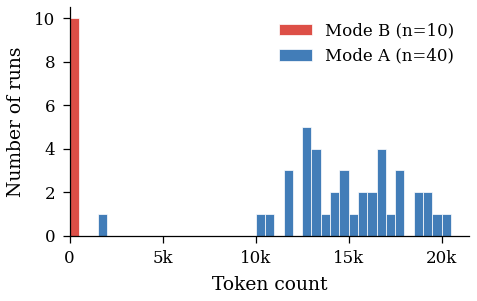

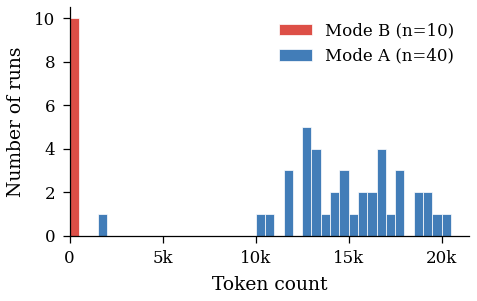

In [3]:
fig = panels.fig_bimodal_histogram(data)
save(fig, "fig01_bimodal")
fig

## Figure 2: Spectral Power Scaling

Section 4.5. Log-log scatter of `spectral_power_low` vs token count, with OLS regression showing superlinear scaling ($\alpha = 1.46$, $R^2 = 0.93$).

Saved fig02_spectral_scaling.pdf and fig02_spectral_scaling.png


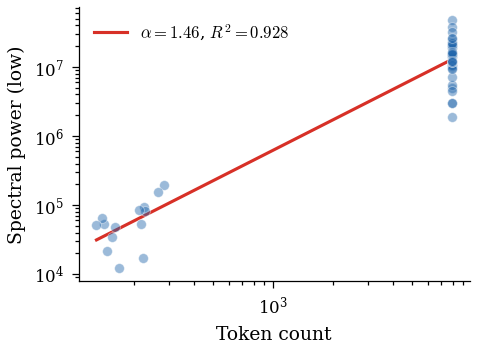

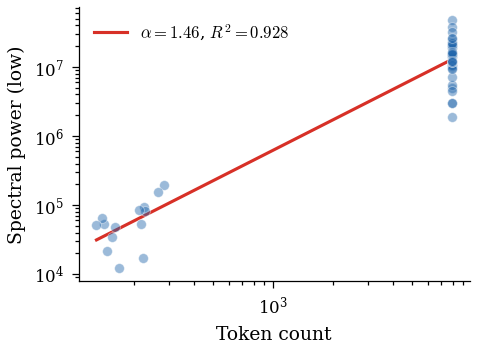

In [4]:
fig = panels.fig_spectral_scaling(data)
save(fig, "fig02_spectral_scaling")
fig

## Figure 3: Partial Correlation Heatmap

Section 4.6. Vocabulary × activation metric partial correlations (controlling for `n_tokens`). Stars mark Bonferroni-significant pairs.

Saved fig03_partial_correlations.pdf and fig03_partial_correlations.png


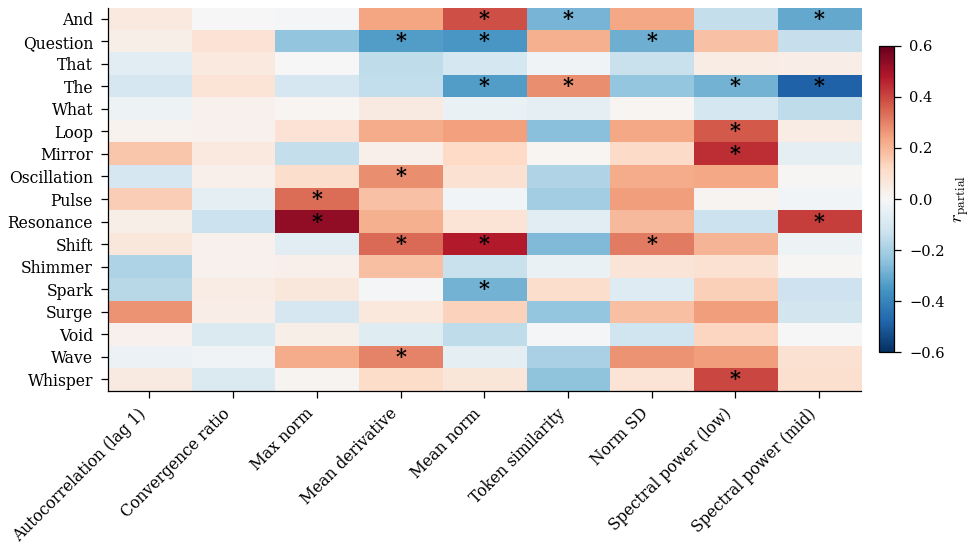

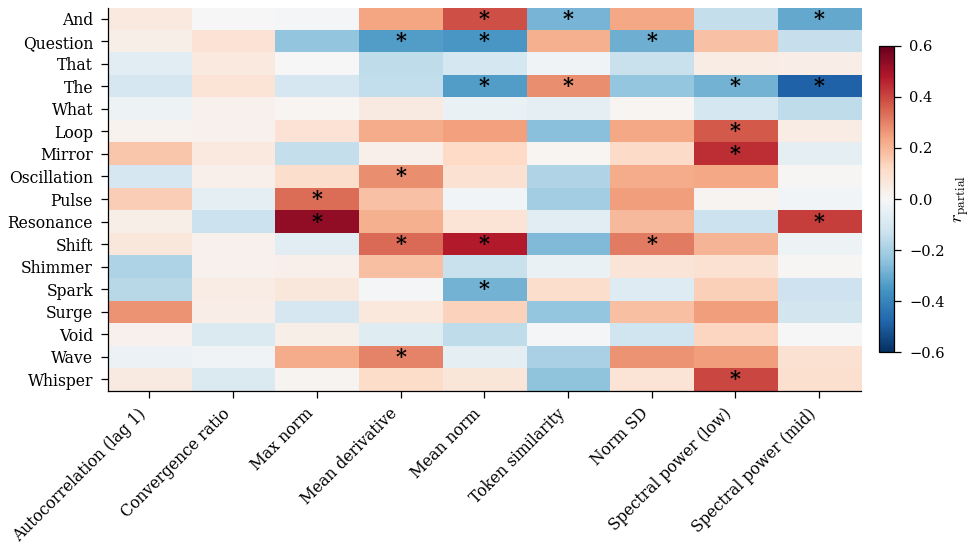

In [5]:
fig = panels.fig_partial_correlation_heatmap(data)
save(fig, "fig03_partial_correlations")
fig

## Figure 4: Metric Convergence by Observation Cutoff

Section 7. Median relative error of activation metrics vs observation cutoff. Length-independent metrics converge within 5% by observation 100; `spectral_power_low` never converges.

Saved fig04_metric_convergence.pdf and fig04_metric_convergence.png


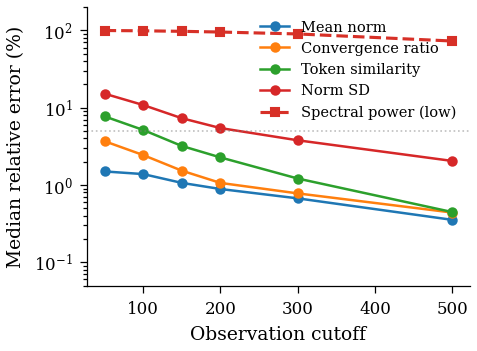

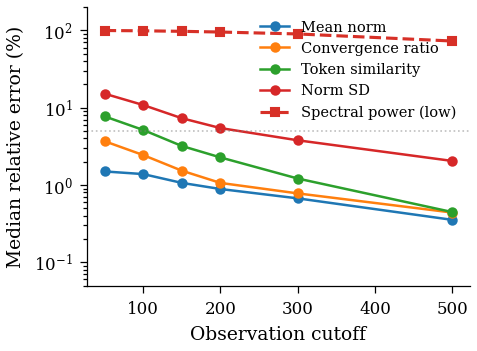

In [6]:
fig = panels.fig_metric_convergence(data)
save(fig, "fig04_metric_convergence")
fig

## Figure 5: Lock-in Resistance by Prompt Condition

Section 8.3–8.4. Lock-in observation across 8 prompt conditions. No significant difference (Kruskal-Wallis $p = 0.32$).

Saved fig05_lock_in_conditions.pdf and fig05_lock_in_conditions.png


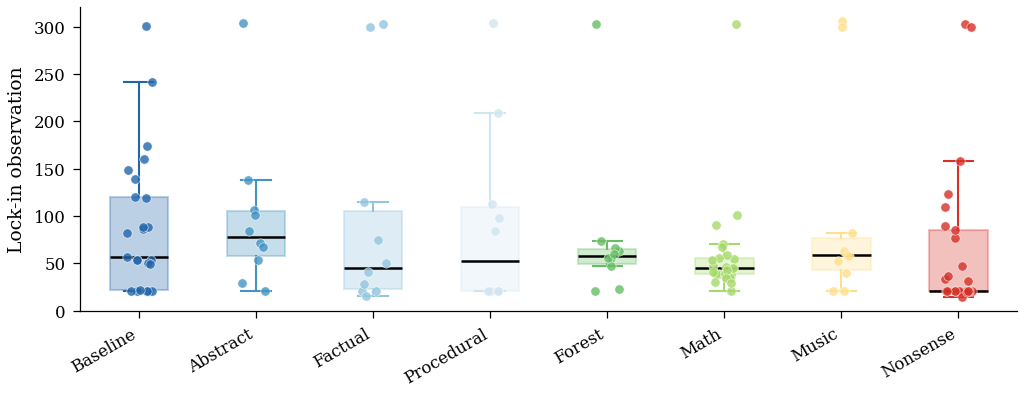

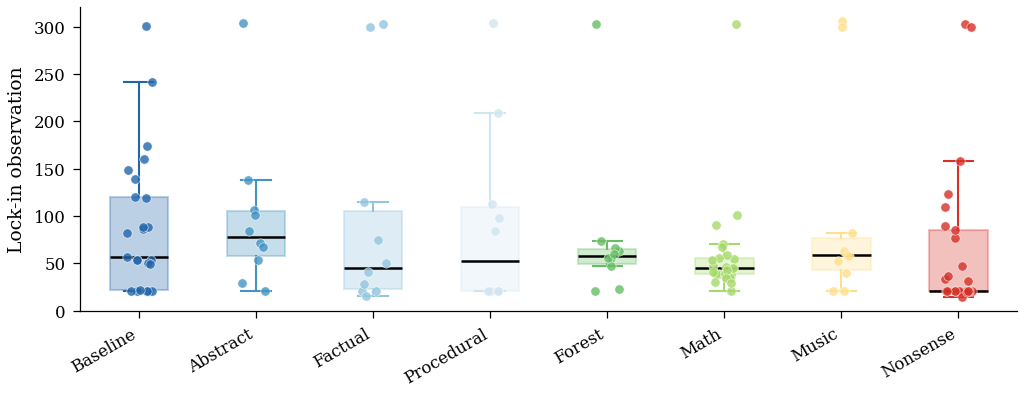

In [7]:
fig = panels.fig_lock_in_by_condition(data)
save(fig, "fig05_lock_in_conditions")
fig

## Figure 6: Lock-in Resistance by Temperature

Section 8.5. Lock-in observation at T = 0.3, 0.7, 1.0. No significant difference (Kruskal-Wallis $p = 0.83$).

Saved fig06_lock_in_temperature.pdf and fig06_lock_in_temperature.png


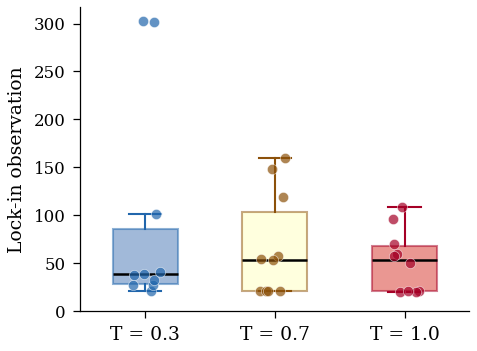

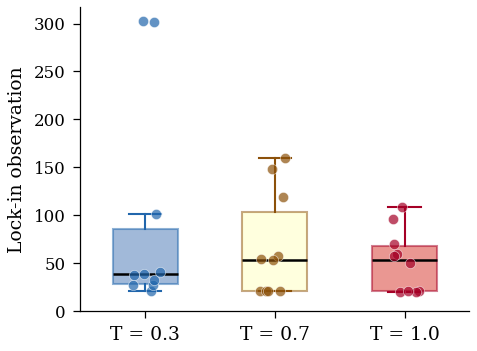

In [8]:
fig = panels.fig_lock_in_by_temperature(data)
save(fig, "fig06_lock_in_temperature")
fig

## Figure 7: F-Statistics by Layer Depth

Section 8.6. Between-condition vs within-condition F-statistics for activation norms and cosine similarity. No layer shows a peak (no "hotspot").

Saved fig07_f_statistics.pdf and fig07_f_statistics.png


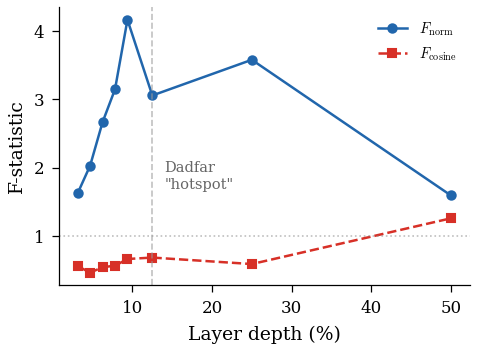

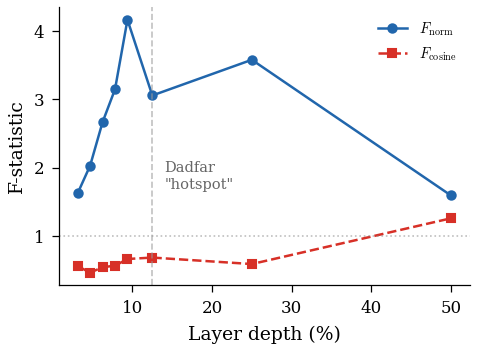

In [9]:
fig = panels.fig_f_statistics(data)
save(fig, "fig07_f_statistics")
fig

## Figure 8: Centroid Cosine Similarity by Layer

Section 8.6.5. Pairwise cosine similarity between condition centroids decreases monotonically with depth (consistent with residual stream accumulation, not localization).

Saved fig08_centroid_cosines.pdf and fig08_centroid_cosines.png


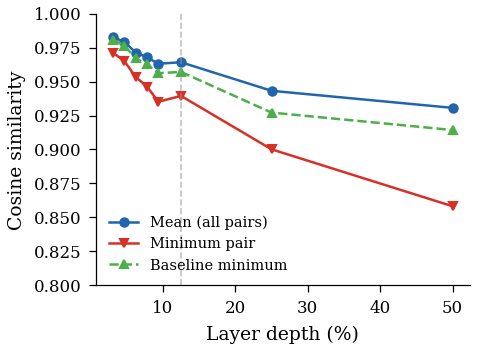

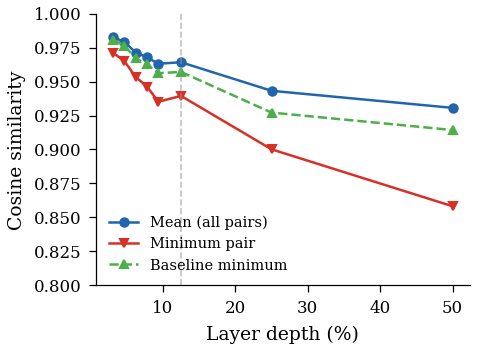

In [10]:
fig = panels.fig_centroid_cosines(data)
save(fig, "fig08_centroid_cosines")
fig

## Figure 9: VAC Survival Across Test Levels

Section 9.1. Left: significant correlation counts before and after length correction. Right: per-condition significant pairs in the controlled experiment (Level 3).

Saved fig09_vac_survival.pdf and fig09_vac_survival.png


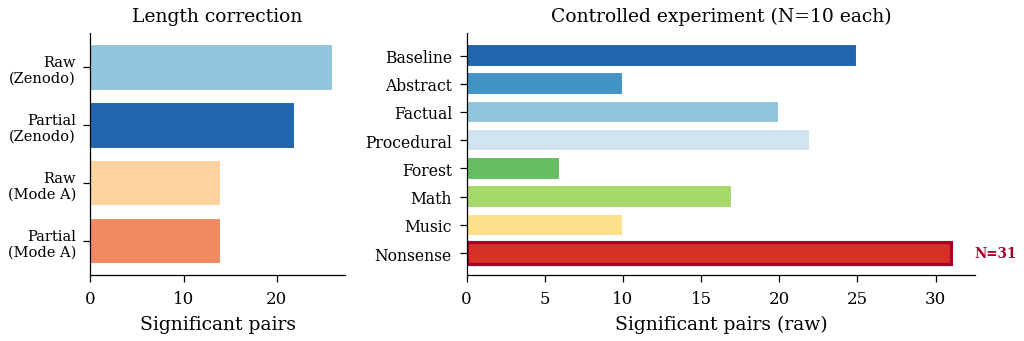

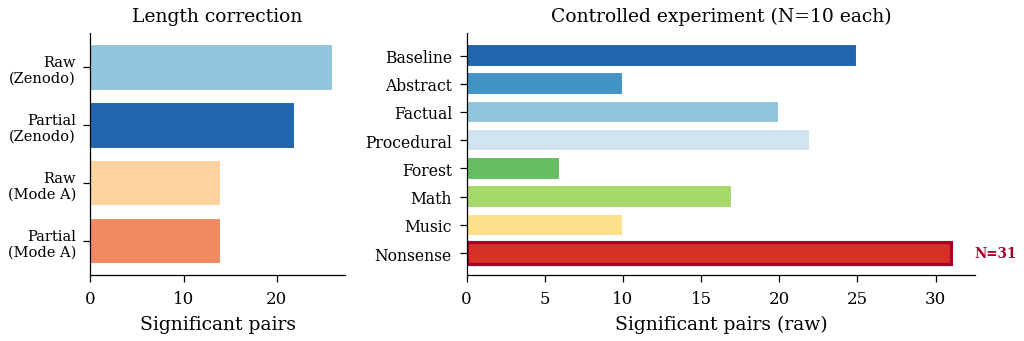

In [11]:
fig = panels.fig_vac_survival(data)
save(fig, "fig09_vac_survival")
fig

## Figure 10: Cross-Model Lock-in Comparison

Section 8.9 / Section 10. Available models shown; missing models silently omitted.

Saved fig10_cross_model.pdf and fig10_cross_model.png


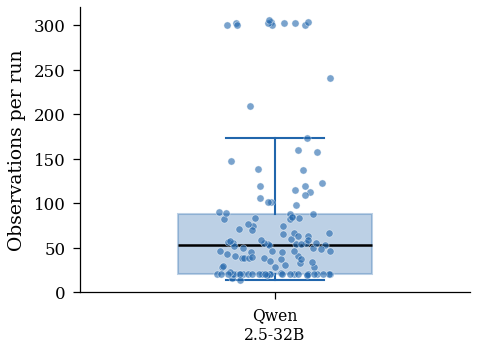

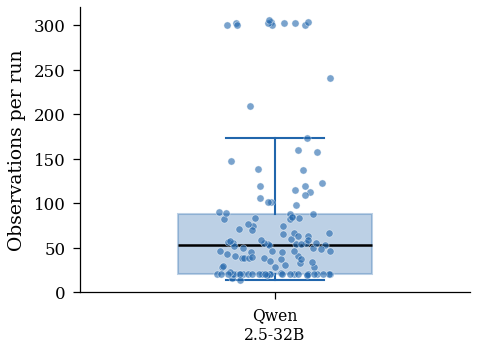

In [12]:
fig = panels.fig_cross_model_lock_in(data)
save(fig, "fig10_cross_model")
fig

## Figure 11: Cross-Model Prompt Compliance Heatmap

Section 8.10. Observation count by model × condition, highlighting model-dependent
compliance with the Pull Methodology format. Gemma 2 9B shows selective refusal
driven by introspection framing, not by content.

Saved fig11_compliance.pdf and fig11_compliance.png


/storage/dadfar_model_self_examination/dadfar-vac-replication/src/figures/panels.py:862: UserWarning: Fig 11: Compliance heatmap (data missing)
  warnings.warn(title)


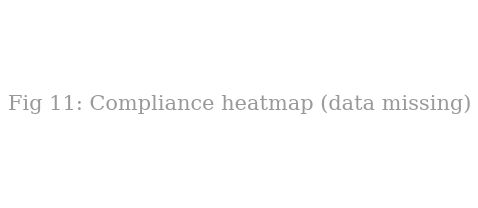

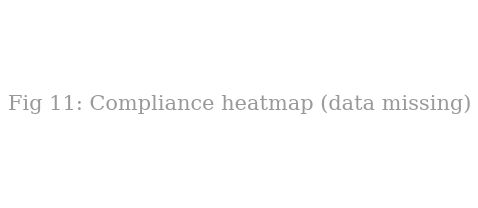

In [13]:
fig = panels.fig_compliance_heatmap(data)
save(fig, "fig11_compliance")
fig

## Figure 12: Cross-Model Direction Analysis

Section 8.9. Cohen's d for introspection vs topic steering directions across models.
High introspection d can reflect topic content rather than genuine self-reference.

Saved fig12_directions.pdf and fig12_directions.png


/storage/dadfar_model_self_examination/dadfar-vac-replication/src/figures/panels.py:862: UserWarning: Fig 12: Direction analysis (no data)
  warnings.warn(title)


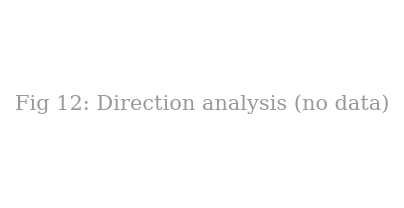

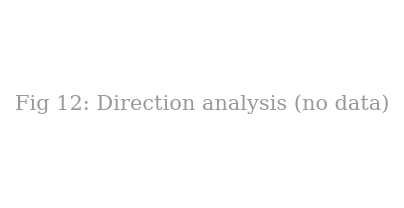

In [14]:
fig = panels.fig_cross_model_directions(data)
save(fig, "fig12_directions")
fig

## Figure 13: VAC Scatter Rebuttal (answers Dadfar Figs 5, 6, 9)

Three-panel rebuttal of Dadfar's central claim. Left: replicate Dadfar's introspective
scatter (mirror vs spectral power). Centre: replicate his descriptive control (correlation
vanishes). Right: our extension showing VAC appears in ALL conditions including nonsense
— the "control" was testing topic specificity, not introspection specificity.

Saved fig13_vac_scatter_rebuttal.pdf and fig13_vac_scatter_rebuttal.png


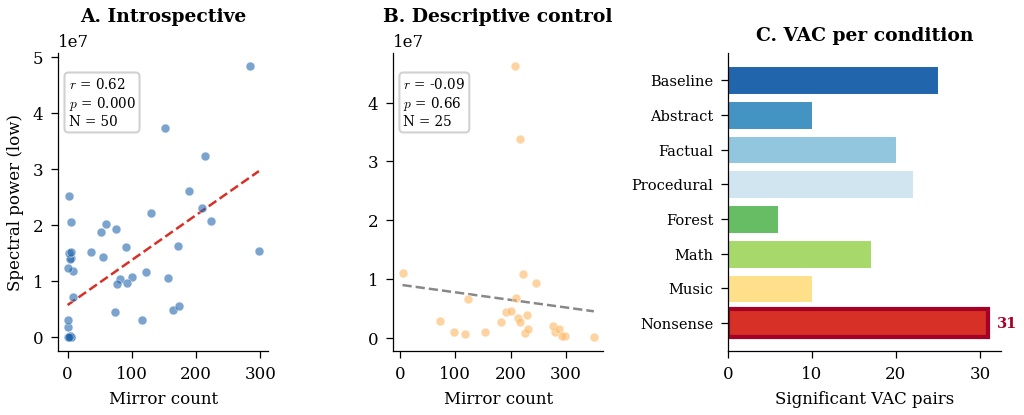

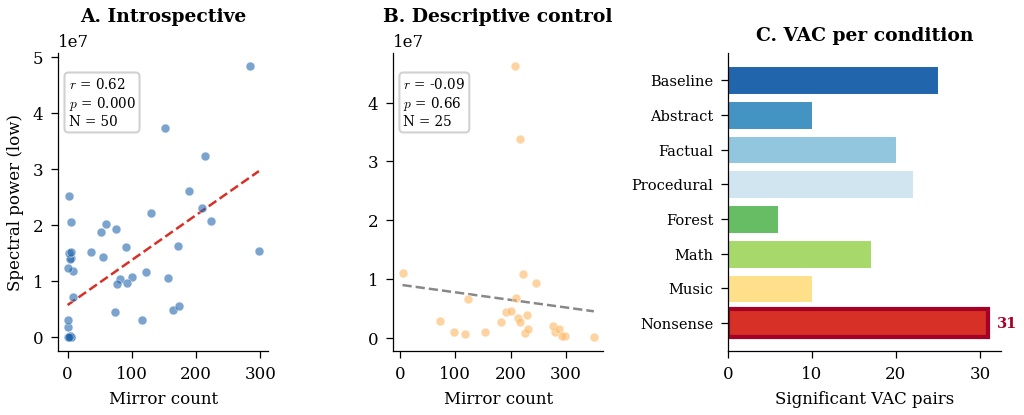

In [15]:
fig = panels.fig_vac_scatter_rebuttal(data)
save(fig, "fig13_vac_scatter_rebuttal")
fig

## Figure 14: Layer Sweep Comparison (answers Dadfar Fig 3)

Side-by-side comparison of Dadfar's Llama 70B layer sweep (Layer 5 dramatically dominates)
versus our Qwen 32B F-statistics (no layer dominates). Demonstrates that the
"layer-specific localization" claimed by Dadfar does not replicate cross-architecture.

Saved fig14_layer_sweep_comparison.pdf and fig14_layer_sweep_comparison.png


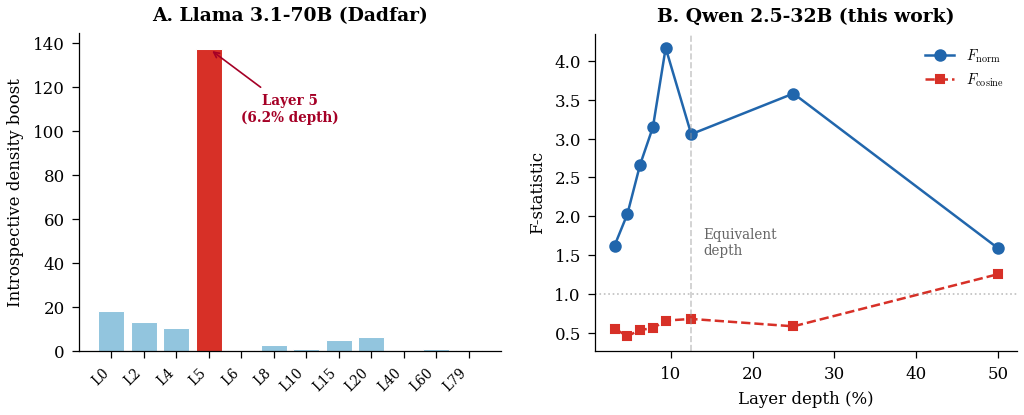

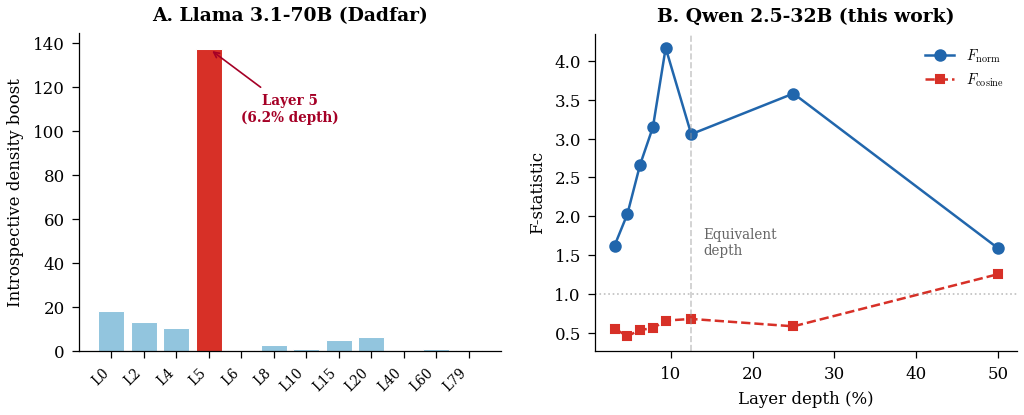

In [16]:
fig = panels.fig_layer_sweep_comparison(data)
save(fig, "fig14_layer_sweep_comparison")
fig

## Figure B1: Mode Classification (Appendix B)

Left: token length histogram from extended baseline. Right: mode proportions across datasets.

Saved figB1_mode_classification.pdf and figB1_mode_classification.png


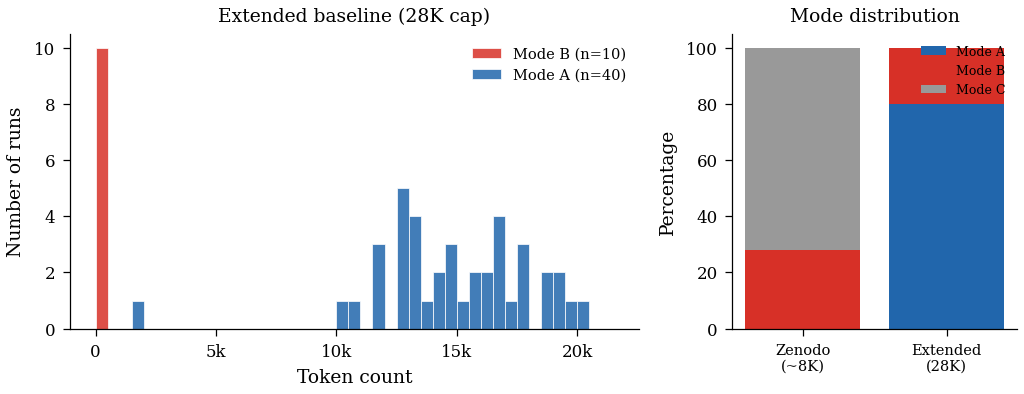

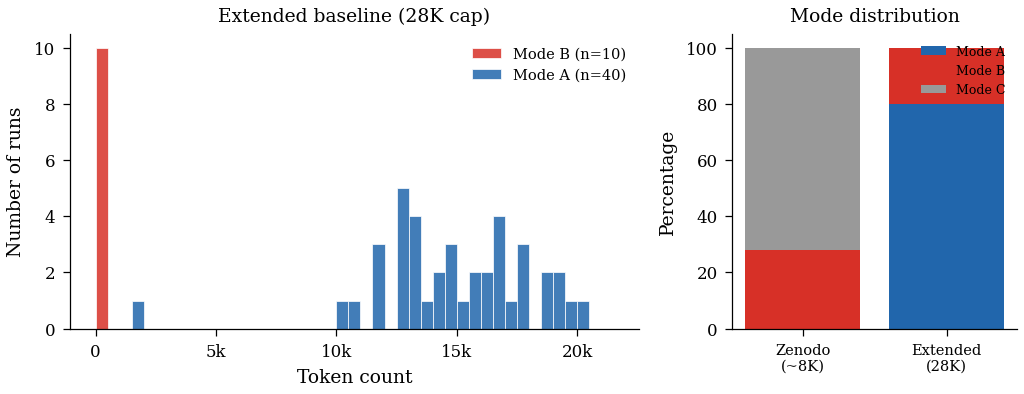

In [17]:
fig = panels.fig_appendix_mode_histogram(data)
save(fig, "figB1_mode_classification")
fig

---

## Summary

All figures saved to `paper1_replication_remediation/figures/` as both PDF (for LaTeX) and PNG (for preview).

In [18]:
import os
figs = sorted(FIGURES_DIR.glob("*.pdf"))
print(f"{len(figs)} figure PDFs generated:")
for f in figs:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} {size_kb:6.1f} KB")

15 figure PDFs generated:
  fig01_bimodal.pdf                          13.3 KB
  fig02_spectral_scaling.pdf                 22.0 KB
  fig03_partial_correlations.pdf             45.4 KB
  fig04_metric_convergence.pdf               18.7 KB
  fig05_lock_in_conditions.pdf               18.0 KB
  fig06_lock_in_temperature.pdf              12.1 KB
  fig07_f_statistics.pdf                     20.6 KB
  fig08_centroid_cosines.pdf                 15.5 KB
  fig09_vac_survival.pdf                     19.3 KB
  fig10_cross_model.pdf                      13.0 KB
  fig11_compliance.pdf                        9.4 KB
  fig12_directions.pdf                        9.2 KB
  fig13_vac_scatter_rebuttal.pdf             31.6 KB
  fig14_layer_sweep_comparison.pdf           37.4 KB
  figB1_mode_classification.pdf              17.5 KB
